# Introduction
This notebook describes the most important questions regarding to the patterns of the electricity price in France using SQL. The database is first created in create_database.py from the cleaned dataframe from 01_data_cleaning.ipynb. 

# Load database

In [161]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DB_path = "../electricity.db"
SQL_path = "../sql/analysis.sql"

conn = sqlite3.connect(DB_path)

In [213]:
with open(SQL_path, "r") as f:
    sql_script = f.read()

In [145]:
def run_query(query, conn):
    return pd.read_sql_query(query, conn)

In [214]:
queries = [q.strip() for q in sql_script.split(";") if q.strip()]

# Q1: Electricity price distribution

In [66]:
df_price = run_query(queries[0], conn)
df_price.head()

,Day-ahead Price (EUR/MWh)
0,23.86
1,22.39
2,20.59
3,16.81
4,17.41


In [67]:
df_price["Day-ahead Price (EUR/MWh)"].describe()

count    78912.000000
mean        82.573143
std         95.270461
min       -134.940000
25%         33.000000
50%         50.000000
75%         89.920000
max       2987.780000
Name: Day-ahead Price (EUR/MWh), dtype: float64

The electricity price in France is highly volatile. The price ranges from negative values to extremely high numbers.

# Q2: Yearly average price trend

In [46]:
df_yearly_avg = run_query(queries[1], conn)
df_yearly_avg

,year,avg_price
0,2016,36.748941
1,2017,44.965311
2,2018,50.198485
3,2019,39.449507
4,2020,32.203133
5,2021,109.171356
6,2022,275.878425
7,2023,96.855878
8,2024,58.018068


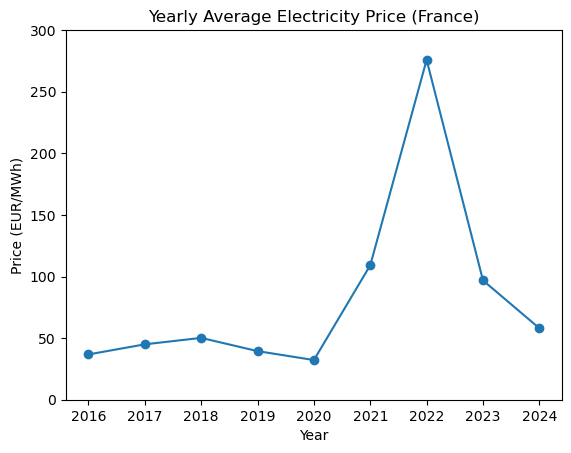

In [200]:
df_yearly_avg.plot(x = "year", y = "avg_price", marker = "o", legend = False)
plt.title("Yearly Average Electricity Price (France)")
plt.ylabel("Price (EUR/MWh)")
plt.ylim([0, 300])
plt.xlabel("Year")
plt.show()

Electricity price in France was geneniunly stable between 2016-2020. However, sharp increases in price appeared from 2021 and lasted to 2022. In 2023 the price descended back to the same level as 2021, and further decreased in 2024. The average price trend corresponds to the energy crisis in 2022.
# Q3: Demand vs price relationship

In [76]:
df_demand_price = run_query(queries[2], conn)
df_demand_price.head()

,Day-ahead Total Load Forecast (MW)_load,Day-ahead Price (EUR/MWh)
0,58600.0,23.86
1,56550.0,22.39
2,56150.0,20.59
3,52600.0,16.81
4,49750.0,17.41


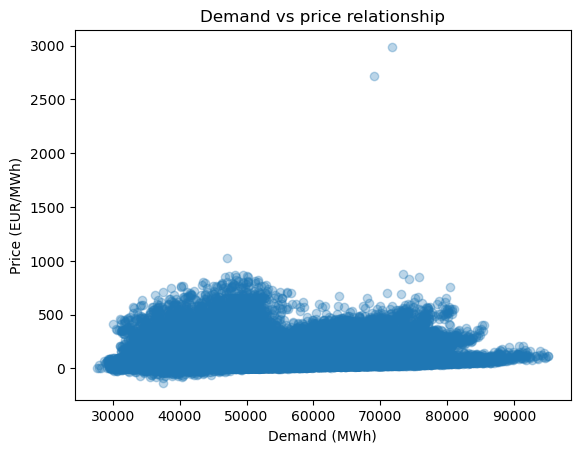

In [77]:
plt.scatter(
    df_demand_price["Day-ahead Total Load Forecast (MW)_load"],
    df_demand_price["Day-ahead Price (EUR/MWh)"],
    alpha= 0.3
)
plt.title("Demand vs price relationship")
plt.xlabel("Demand (MWh)")
plt.ylabel("Price (EUR/MWh)")
plt.show()

Demand and price doesn't show a clear linear relationship. This is probably due to the influences from multiple variables, such as the renewable generations, the gas price, and international exchange.
# Q4: Residual demand vs price relationship

In [130]:
df_resi_deman = run_query(queries[3], conn)
df_resi_deman.head()

,demand_bucket,avg_price
0,LOW,71.235745
1,MEDIUM,84.107257
2,HIGH,102.495757


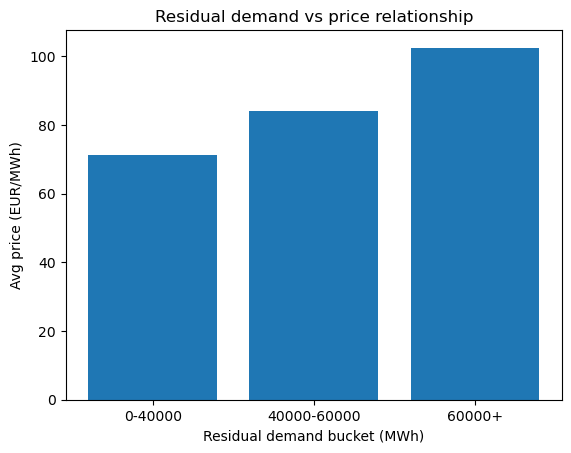

In [139]:
plt.bar(x = df_resi_deman["demand_bucket"], height = df_resi_deman["avg_price"])
plt.xticks(ticks = ["LOW", "MEDIUM", "HIGH"], labels = ["0-40000", "40000-60000", "60000+"])
plt.xlabel("Residual demand bucket (MWh)")
plt.ylabel("Avg price (EUR/MWh)")
plt.title("Residual demand vs price relationship")
plt.show()

Binning the residual demand into three boxes, the average price increases as the residual demand increases. 
# Q5: Hourly price

In [ ]:
df_hour_price = run_query(queries[4], conn)
df_hour_price

,hour,hourly_price
0,0,77.058954
1,1,70.514206
2,2,67.351402
3,3,61.989592
4,4,60.202594
5,5,65.524194
6,6,77.849821
7,7,91.750724
8,8,97.644632
9,9,93.973139


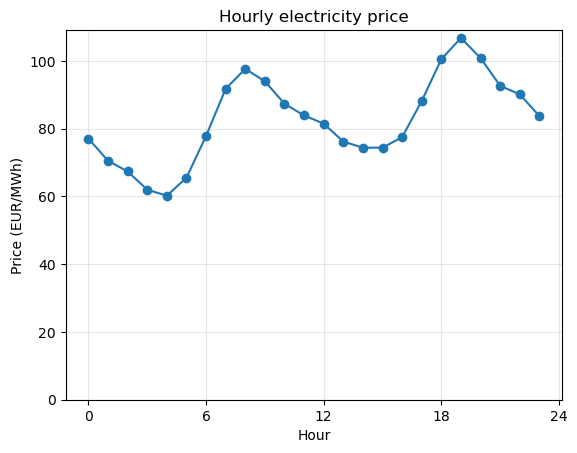

In [ ]:
df_hour_price.plot(x = "hour", y = "hourly_price", marker = "o", legend = False)
plt.title("Hourly electricity price")
plt.xlabel("Hour")
plt.xticks(range(0, 25, 6))
plt.grid(alpha = 0.3)
plt.ylabel("Price (EUR/MWh)")
plt.yticks(range(0, 110, 20))
plt.show()

Electricity price show interday patterns. The highest price corresponds to evening peak hours when populations arrive home and utilise home appliances extensively at the same time period. The second price peaks at the morning rush hour when industries start to engage machinaries. Between the two peaks, the price decreases and then increases, influenced by demand, renewable generations, etc.
# Q6: Solar generation

In [ ]:
df_solar_gen = run_query(queries[5], conn)
df_solar_gen

,hour,solar_avg_gen
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.000000
5,5,0.000000
6,6,0.699386
7,7,82.652162
8,8,463.347777
9,9,1435.843574


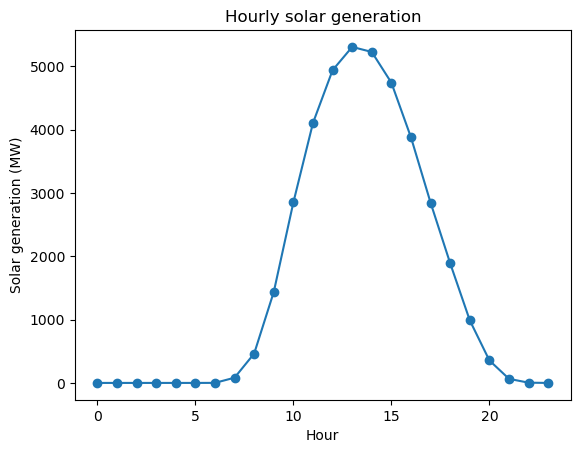

In [109]:
df_solar_gen.plot(x = "hour", y = "solar_avg_gen", marker = "o", legend = False)
plt.title("Hourly solar generation")
plt.xlabel("Hour")
plt.ylabel("Solar generation (MW)")
plt.show()

The hourly solar generation shows a bell shape with a longer tail on the left side. This corresponds perfectly to the solar exposure during one day: During the night there is no solar generation, and from midday to early afternoon the solar exposure is the highest, followed by the decrease of solar energy as the evening embarks.
# Q7: Negative price 

In [ ]:
df_neg_price = run_query(queries[6], conn)
df_neg_price

,year,negative_hours
0,2016,2
1,2017,4
2,2018,11
3,2019,27
4,2020,102
5,2021,64
6,2022,4
7,2023,147
8,2024,352


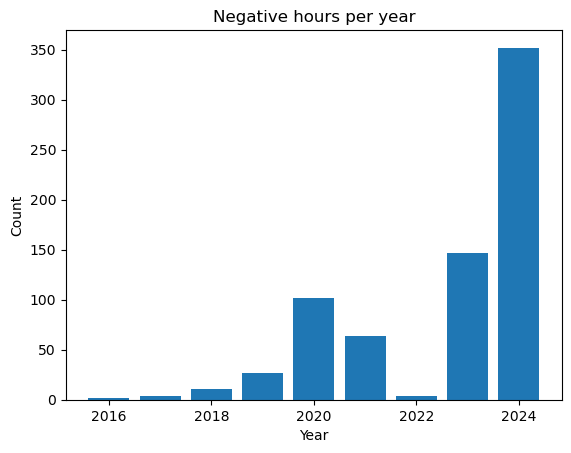

In [116]:
plt.bar(x = df_neg_price["year"], height = df_neg_price["negative_hours"])
plt.title("Negative hours per year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

The occurance of negative price appears to be increasing during 2016-2020 and shows a slight drop in 2021. In 2022 the negative price event dropped dramatically due to the structural disruption during the energy crisis. Since 2023, the negative price counts bounced back expotentially. 
# Q8.1: Extreme price events

In [159]:
df_extrem_price = run_query(queries[7], conn)
df_extrem_price

,year,extreme_hours,pct_of_all_extrem_hours
0,2016,9,0.0
1,2017,2,0.0
2,2018,4,0.0
3,2020,1,0.0
4,2021,1277,17.0
5,2022,5847,80.0
6,2023,121,1.0
7,2024,25,0.0


Extreme events happen most frequently in 2022, followed by 2021. In addition, the scarcity events show descreasing trend from 2023 to 2024.
# Q8.2 Top 20 price spikes 

In [183]:
df_top20_price = run_query(queries[8], conn)
df_top20_price

,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_onshore,Day-ahead (MW)_solar,Day-ahead Price (EUR/MWh)
0,71750.0,3409.00,0.00,2987.78
1,69000.0,3252.48,0.00,2712.99
2,47050.0,2011.51,0.00,1021.73
3,73450.0,2052.35,0.00,874.01
4,49400.0,2552.89,1696.84,871.00
5,48250.0,2148.64,255.97,870.00
6,47400.0,2878.66,243.87,860.89
7,50100.0,1942.48,1772.16,859.45
8,48400.0,2227.14,3977.76,851.81
9,75750.0,1971.12,0.00,850.07


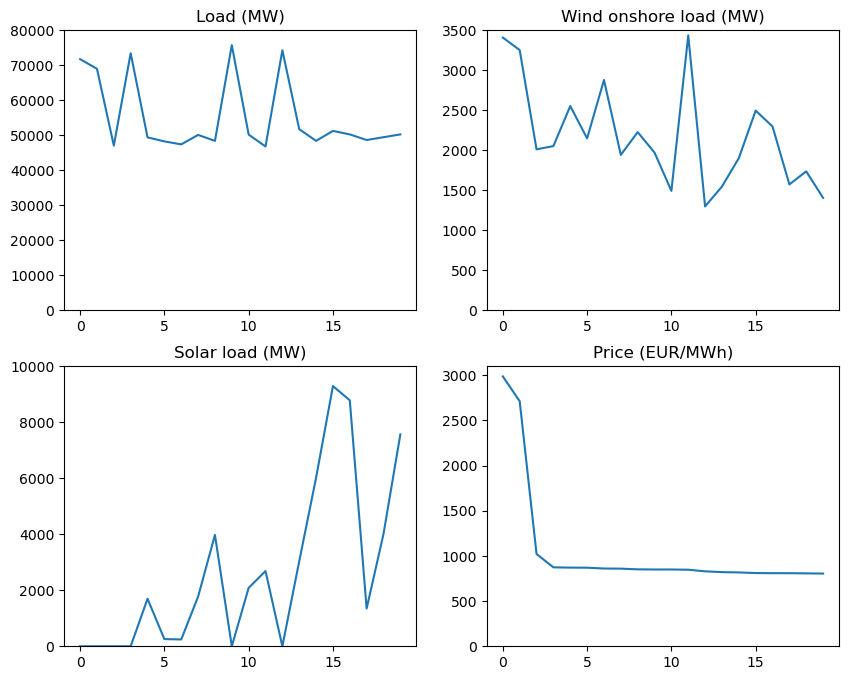

In [198]:
fig, axes = plt.subplots(2, 2, figsize = (10, 8))

axes[0, 0].plot(df_top20_price["Day-ahead Total Load Forecast (MW)_load"])
axes[0, 1].plot(df_top20_price["Day-ahead (MW)_wind_onshore"])
axes[1, 0].plot(df_top20_price["Day-ahead (MW)_solar"])
axes[1, 1].plot(df_top20_price["Day-ahead Price (EUR/MWh)"])

axes[0, 0].set_title("Load (MW)")
axes[0, 1].set_title("Wind onshore load (MW)")
axes[1, 0].set_title("Solar load (MW)")
axes[1, 1].set_title("Price (EUR/MWh)")

axes[0, 0].set_ylim([0, 80000])
axes[0, 1].set_ylim([0, 3500])
axes[1, 0].set_ylim([0, 10000])
axes[1, 1].set_ylim([0, 3100])
plt.show()

The demand peak fluctuations do not necessarily align with the price spikes. Renewable generations likely contributed to the decrease of the price peaks.
# Q8.3 Extreme events by hour

In [188]:
df_extrem_by_hour = run_query(queries[9], conn)
df_extrem_by_hour

,hour,extrem_by_hour,pct_of_all_extrem_by_hour
0,0,274,3.0
1,1,236,3.0
2,2,220,3.0
3,3,188,2.0
4,4,184,2.0
5,5,217,2.0
6,6,297,4.0
7,7,351,4.0
8,8,383,5.0
9,9,376,5.0


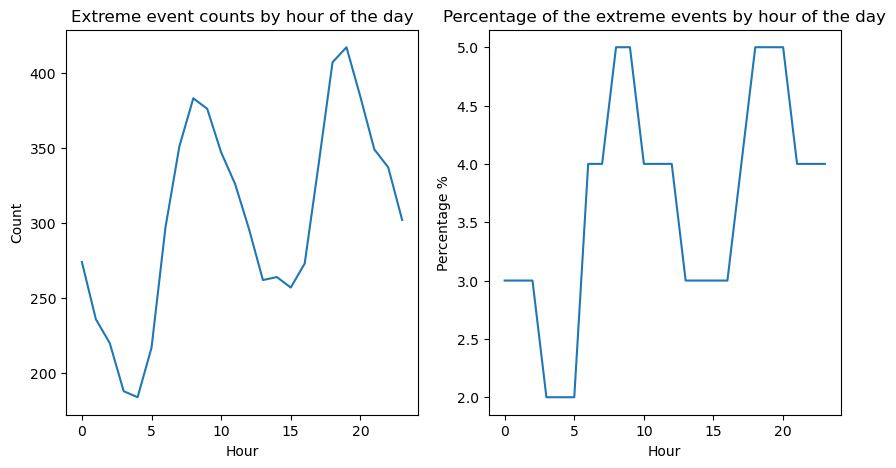

In [208]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(df_extrem_by_hour["extrem_by_hour"])
ax[1].plot(df_extrem_by_hour["pct_of_all_extrem_by_hour"])
ax[0].set_title("Extreme event counts by hour of the day")
ax[1].set_title("Percentage of the extreme events by hour of the day")

ax[0].set_xlabel("Hour")
ax[1].set_xlabel("Hour")

ax[0].set_ylabel("Count")
ax[1].set_ylabel("Percentage %")
plt.show()

Price spikes follows the same pattern as the price distribution within one day. The evening (from 18h) and morning (about 8h) rush hours contribute to the increase of the price spikes.
# Q8.4 Extreme events by month

In [215]:
df_extrem_by_month = run_query(queries[10], conn)
df_extrem_by_month

,month,count_extrem_month,pct_of_all_extrem_by_month
0,1,541,7.0
1,2,265,3.0
2,3,707,9.0
3,4,478,6.0
4,5,347,4.0
5,6,474,6.0
6,7,701,9.0
7,8,737,10.0
8,9,689,9.0
9,10,518,7.0


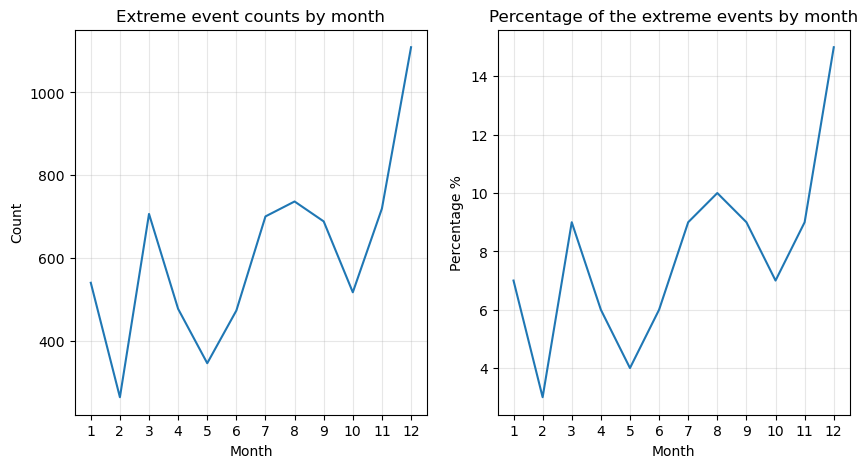

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(df_extrem_by_month["count_extrem_month"])
ax[1].plot(df_extrem_by_month["pct_of_all_extrem_by_month"])
ax[0].set_title("Extreme event counts by month")
ax[1].set_title("Percentage of the extreme events by month")

ax[0].set_xticks(ticks = range(0, 12), labels = range(1, 13))
ax[1].set_xticks(ticks = range(0, 12), labels = range(1, 13))

ax[0].set_xlabel("Month")
ax[1].set_xlabel("Month")

ax[0].set_ylabel("Count")
ax[1].set_ylabel("Percentage %")
ax[0].grid(alpha = 0.3)
ax[1].grid(alpha = 0.3)

plt.show()

In November and December, which are the beginning of winter season, the price spikes much more than the rest of the year, which is likely due to the demand of heating. Jan and Feb show a decrease of price spikes, possibly due to the vacation seasons. Summer months (July-Sep) show a stable price extreme event counts, which is likely due to the increasing usage of air-conditioning in offices, transportations, and homes.
# Q8.5 System conditions during extreme prices

In [247]:
df_during_extreme = run_query(queries[11], conn)
df_during_extreme = df_during_extreme.transpose().reset_index()
df_during_extreme.columns = ["Parameter", "Value"]
df_during_extreme

,Parameter,Value
0,avg_load,54851.838663
1,avg_wind_offshore,1.776832
2,avg_wind_onshore,3553.934743
3,avg_solar,1894.747947
4,avg_price,327.277888


In [230]:
df_overall = run_query(queries[12], conn)
df_overall

,avg_load,avg_wind_offshore,avg_wind_onshore,avg_solar,avg_price
0,52082.498517,58.911953,3869.03169,1631.433275,82.573143


/var/folders/z4/7bgbw8p550b8mfxtzx6_bgy80000gp/T/ipykernel_38256/3728987083.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(labels = df_during_extreme["Parameter"], rotation = 45, ha = "right")


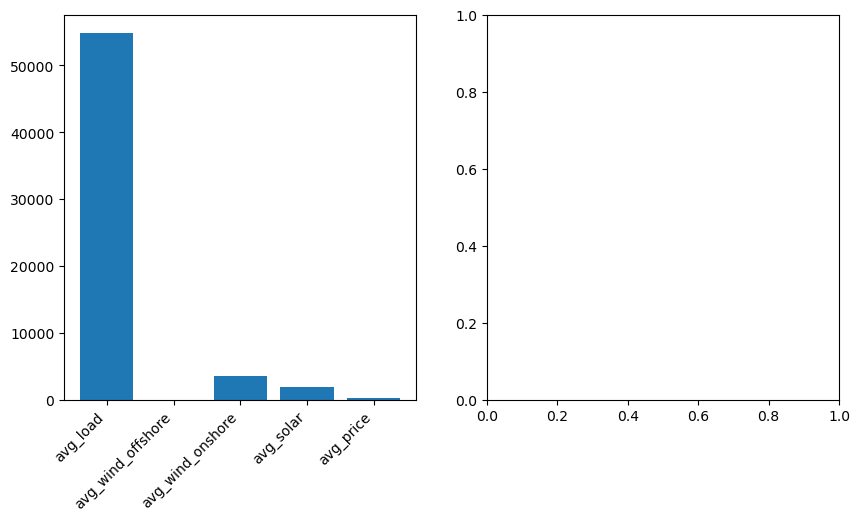

In [263]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].bar(x = df_during_extreme["Parameter"], height = df_during_extreme["Value"])
#ax[1].bar(x = df_overall)
ax[0].set_xticklabels(labels = df_during_extreme["Parameter"], rotation = 45, ha = "right")
plt.show()

In [140]:
conn.close()

# Conclusions